# Library

In [16]:
library(Rssa)

# Data

In [17]:
df <- read.csv("../data/air_traffic.csv")

Pada analisis ini data yang digunakan dari tahun 2003 sampai dengan 2019.

In [18]:
df <- df[df$Year <= 2019, ]

Variabel yang digunakan adalah variabel RPM.

In [19]:
df$RPM <- as.numeric(gsub(",", "", df$RPM))

In [20]:
df

,Year,Month,Dom_Pax,Int_Pax,Pax,Dom_Flt,Int_Flt,Flt,Dom_RPM,Int_RPM,RPM,Dom_ASM,Int_ASM,ASM,Dom_LF,Int_LF,LF
,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,2003,1,"43,032,450","4,905,830","47,938,280","785,160","57,667","842,827","36,211,422","12,885,980",49097402,"56,191,300","17,968,572","74,159,872",64.44,71.71,66.20
2,2003,2,"41,166,780","4,245,366","45,412,146","690,351","51,259","741,610","34,148,439","10,715,468",44863907,"50,088,434","15,587,880","65,676,314",68.18,68.74,68.31
3,2003,3,"49,992,700","5,008,613","55,001,313","797,194","58,926","856,120","41,774,564","12,567,068",54341633,"57,592,901","17,753,174","75,346,075",72.53,70.79,72.12
4,2003,4,"47,033,260","4,345,444","51,378,704","766,260","55,005","821,265","39,465,980","10,370,592",49836572,"54,639,679","15,528,761","70,168,440",72.23,66.78,71.02
5,2003,5,"49,152,352","4,610,834","53,763,186","789,397","55,265","844,662","41,001,934","11,575,026",52576960,"55,349,897","15,629,821","70,979,718",74.08,74.06,74.07
6,2003,6,"52,209,516","5,411,504","57,621,020","798,351","58,225","856,576","44,492,972","13,918,185",58411157,"56,555,517","17,191,579","73,747,096",78.67,80.96,79.20
7,2003,7,"55,810,773","6,191,120","62,001,893","831,619","62,957","894,576","48,321,924","15,516,794",63838718,"59,617,048","18,701,759","78,318,807",81.05,82.97,81.51
8,2003,8,"53,920,973","6,272,332","60,193,305","830,737","63,760","894,497","46,982,527","15,906,430",62888957,"59,634,190","19,144,885","78,779,075",78.78,83.08,79.83
9,2003,9,"44,213,408","4,824,596","49,038,004","781,804","54,017","835,821","36,819,820","13,570,889",50390709,"54,973,852","17,820,478","72,794,329",66.98,76.15,69.22


Buat objek timeseries. Karena data bersifat tahunan, maka frekuensi diset ke 12

In [21]:
data <- ts(df$RPM, frequency = 12, start = c(2003, 1))

## Plot Data

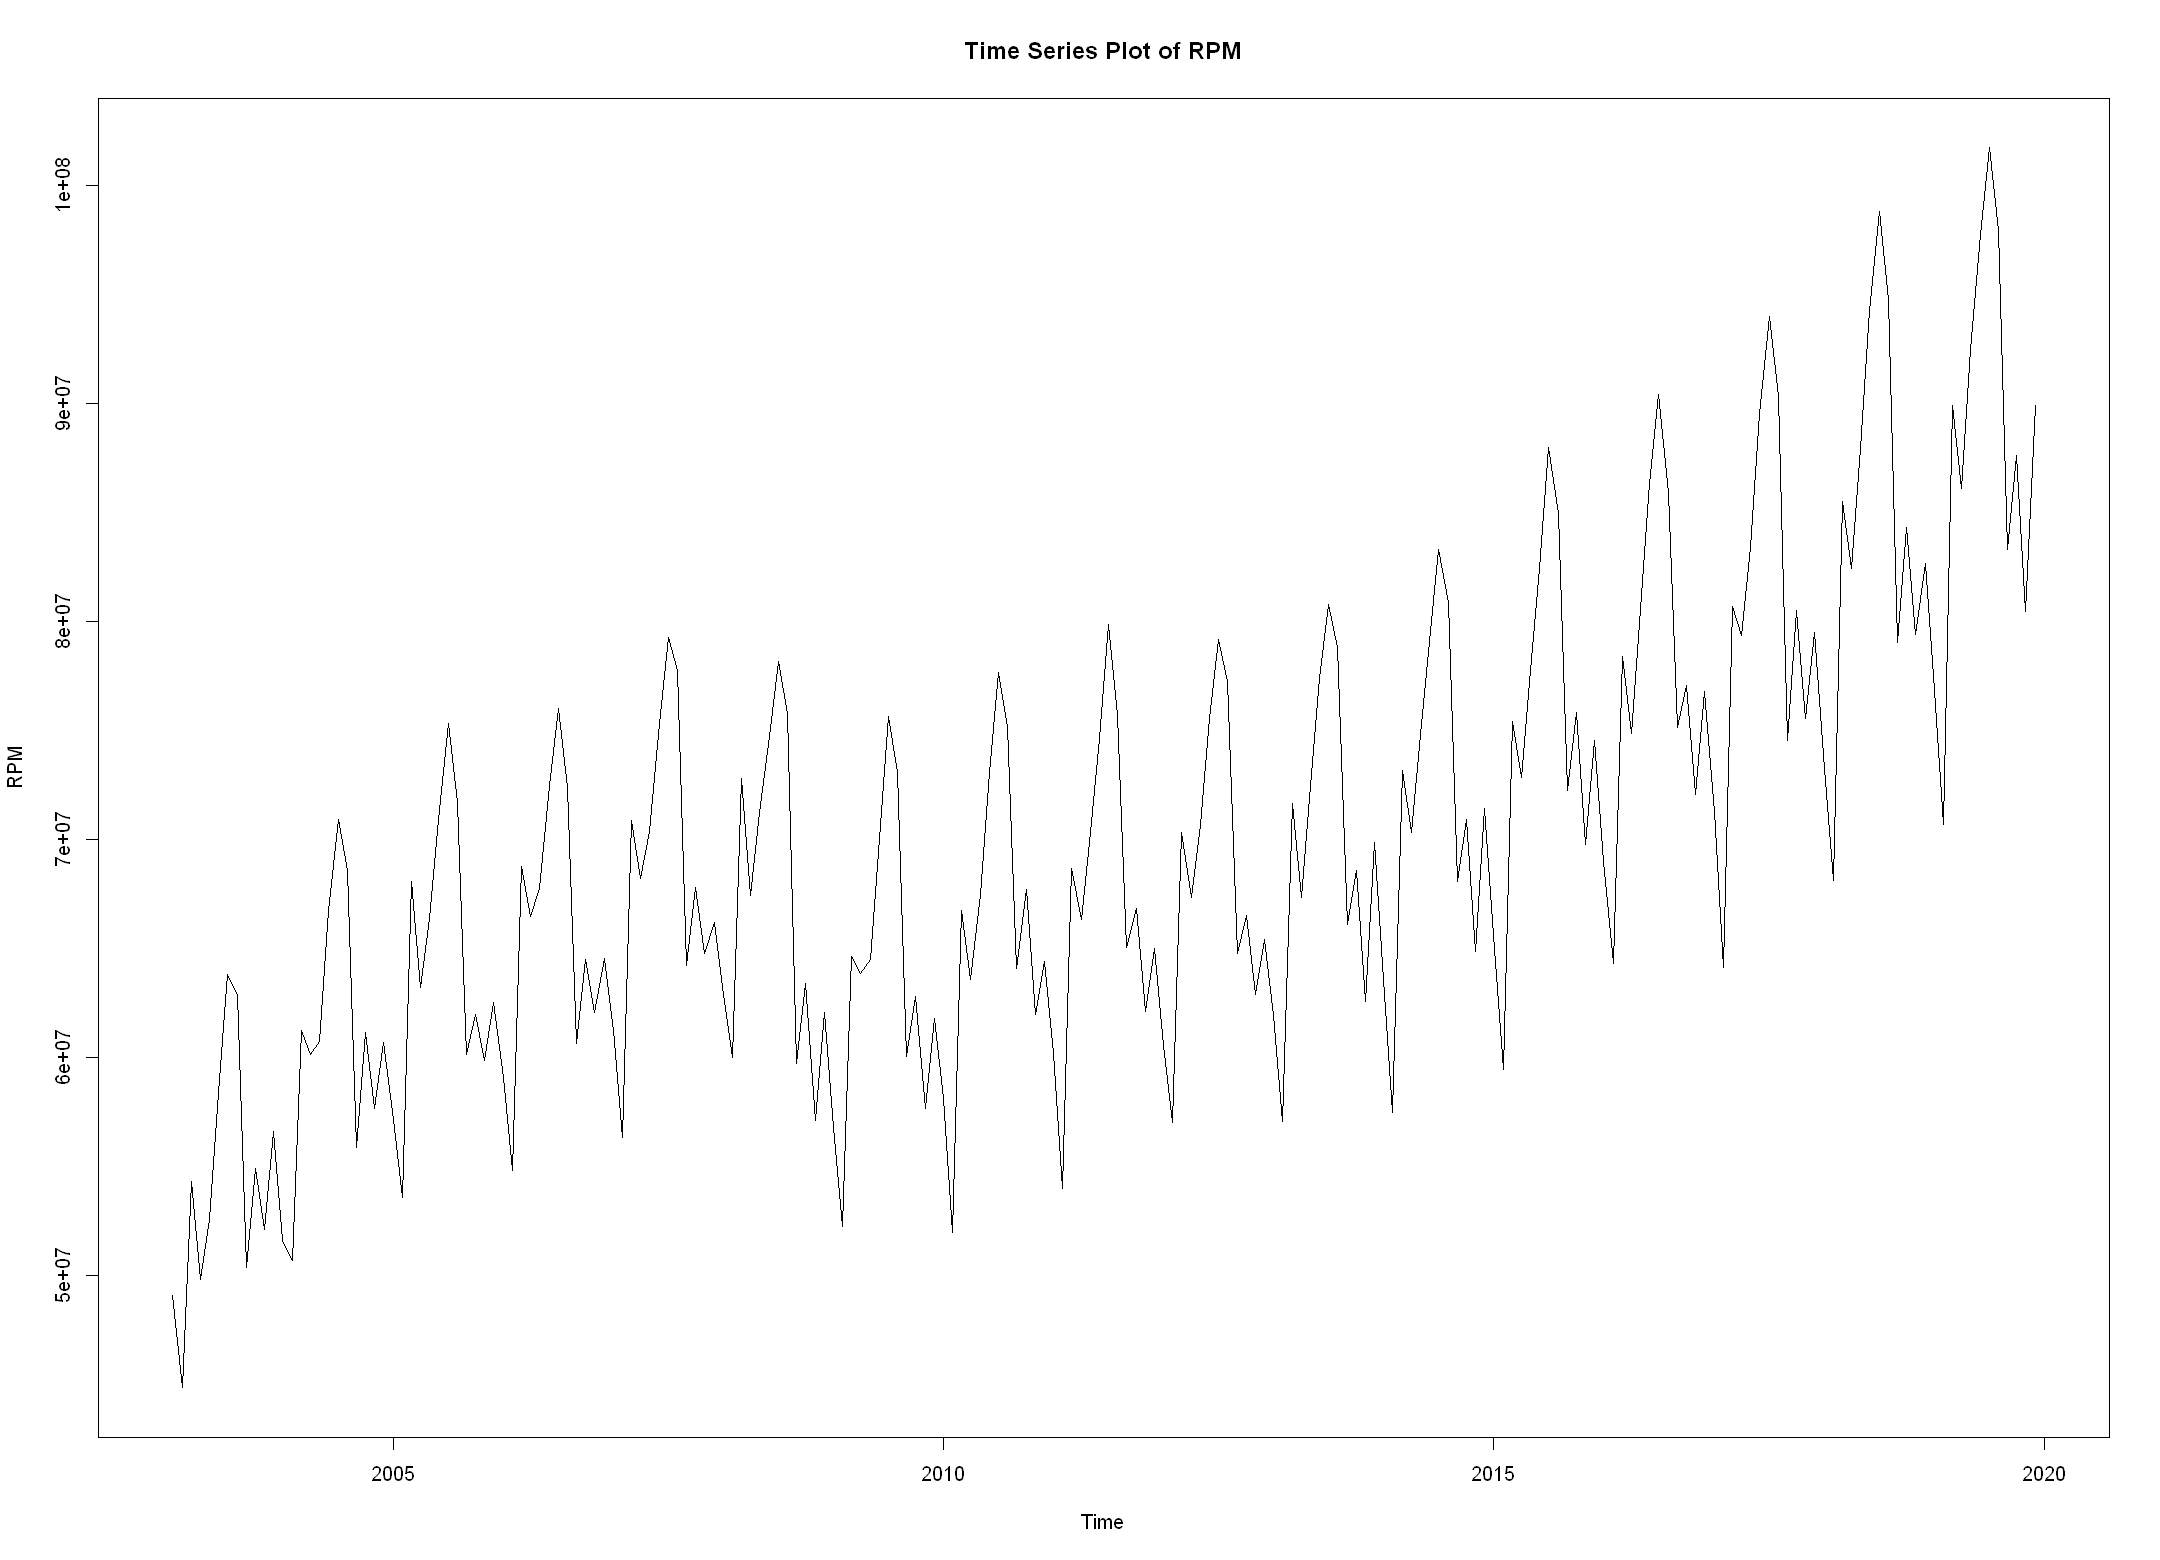

In [22]:
# Plot time series data
options(repr.plot.width=18, repr.plot.height=13)
plot(data, main = "Time Series Plot of RPM", xlab = "Time", ylab = "RPM")

In [23]:
n <- length(data)
n

[1] 204

# Splitting Data

Pembagian data train dan data test dilakukan dengan proporsi 80:20.

In [24]:
test_size <- floor(0.2 * n)

In [25]:
train <- data[1:(n - test_size)]
test  <- data[(n - test_size + 1):n]

In [26]:
length(train)
length(test)

[1] 164

[1] 40

Menghitung panjang data train dibagi dua. Hal ini dilakukan untuk menentukan variabel L1, dimana maksnya adalah n/2

In [27]:
n_per_dua <- floor(length(train) / 2)
n_per_dua

[1] 82

# Dekomposisi

Pada tahap dekomposisi, untuk parameter L1 atau panjang window di set pada nilai 36.  Nilai 36 dipilih karena merupakan bagian dari kelipatan dari pola musiman tahunan. 
Tahap ini akan menguraikan deret waktu menjadi komponen-komponen seperti trend, musiman (seasonal), dan noise, yang kemudian bisa digunakan untuk rekonstruksi atau forecasting.

Fungsi `ssa` melakukan dekomposisi pada data train

In [28]:
L1 <- 36
ssaAT <- ssa(train, L = L1, kind = "1d-ssa")

## Visualisasi Komponen SSA

## Plot Eigenvalues

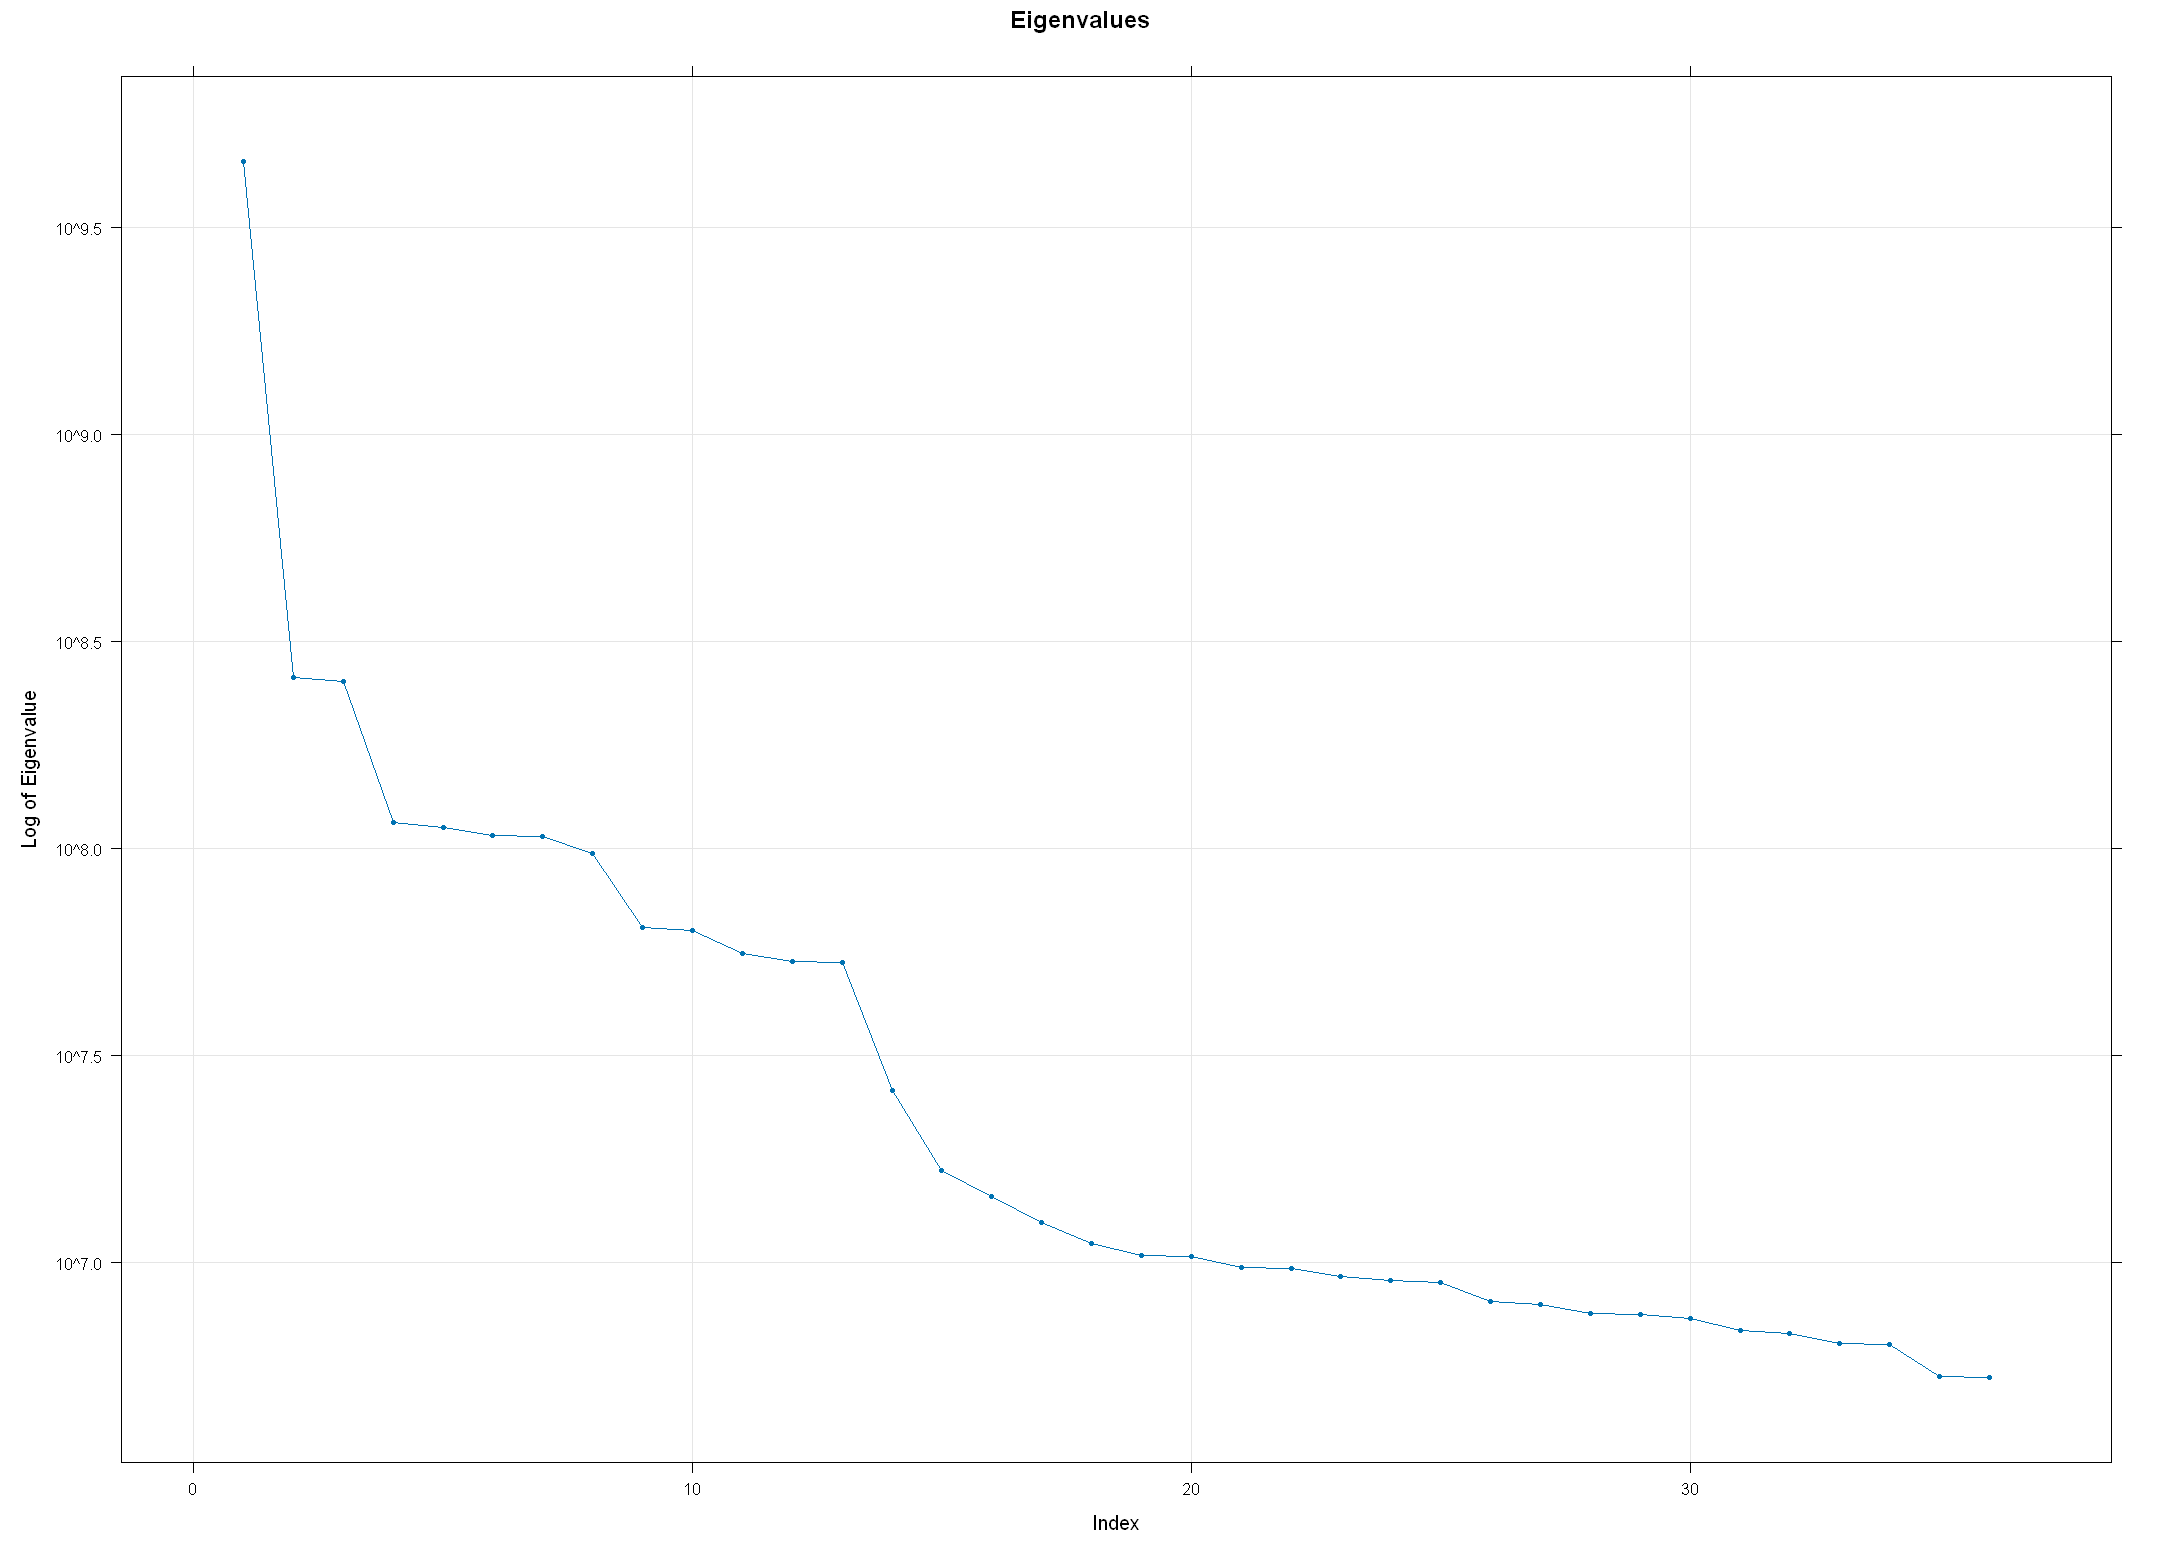

In [29]:
plot(ssaAT, ylab = "Log of Eigenvalue", main = "Eigenvalues")

## Plot Eigenvectors

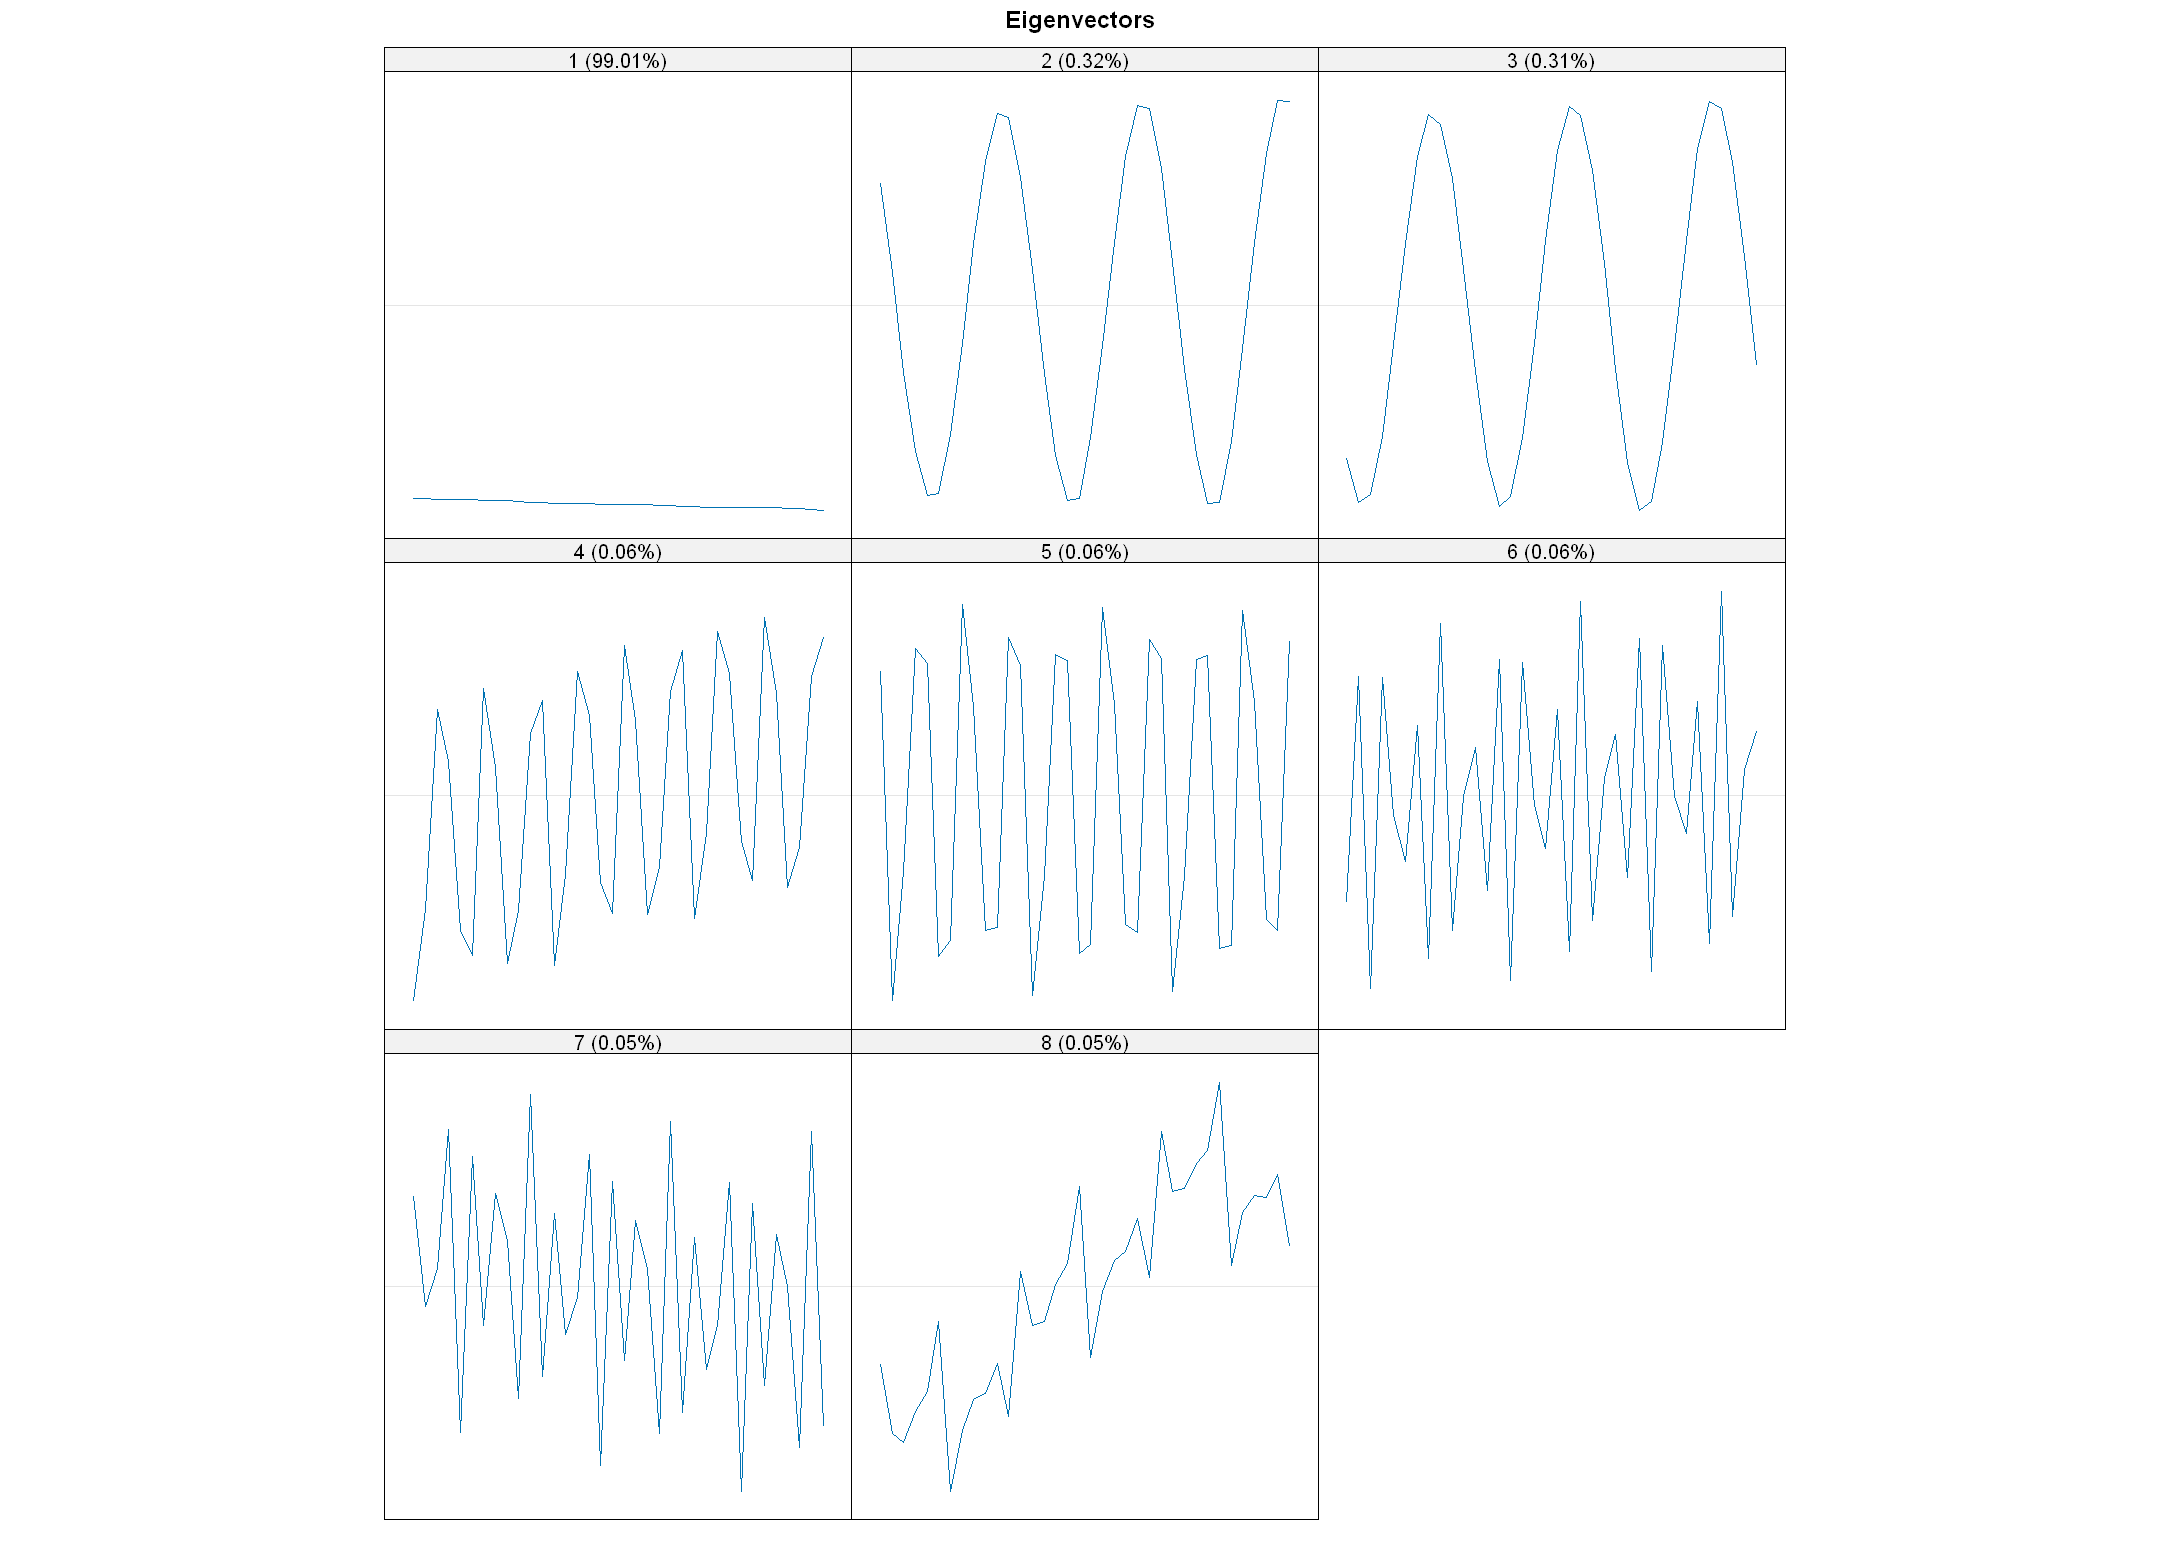

In [30]:
plot(ssaAT, type = "vectors", idx = 1:8)

## Plot Pair

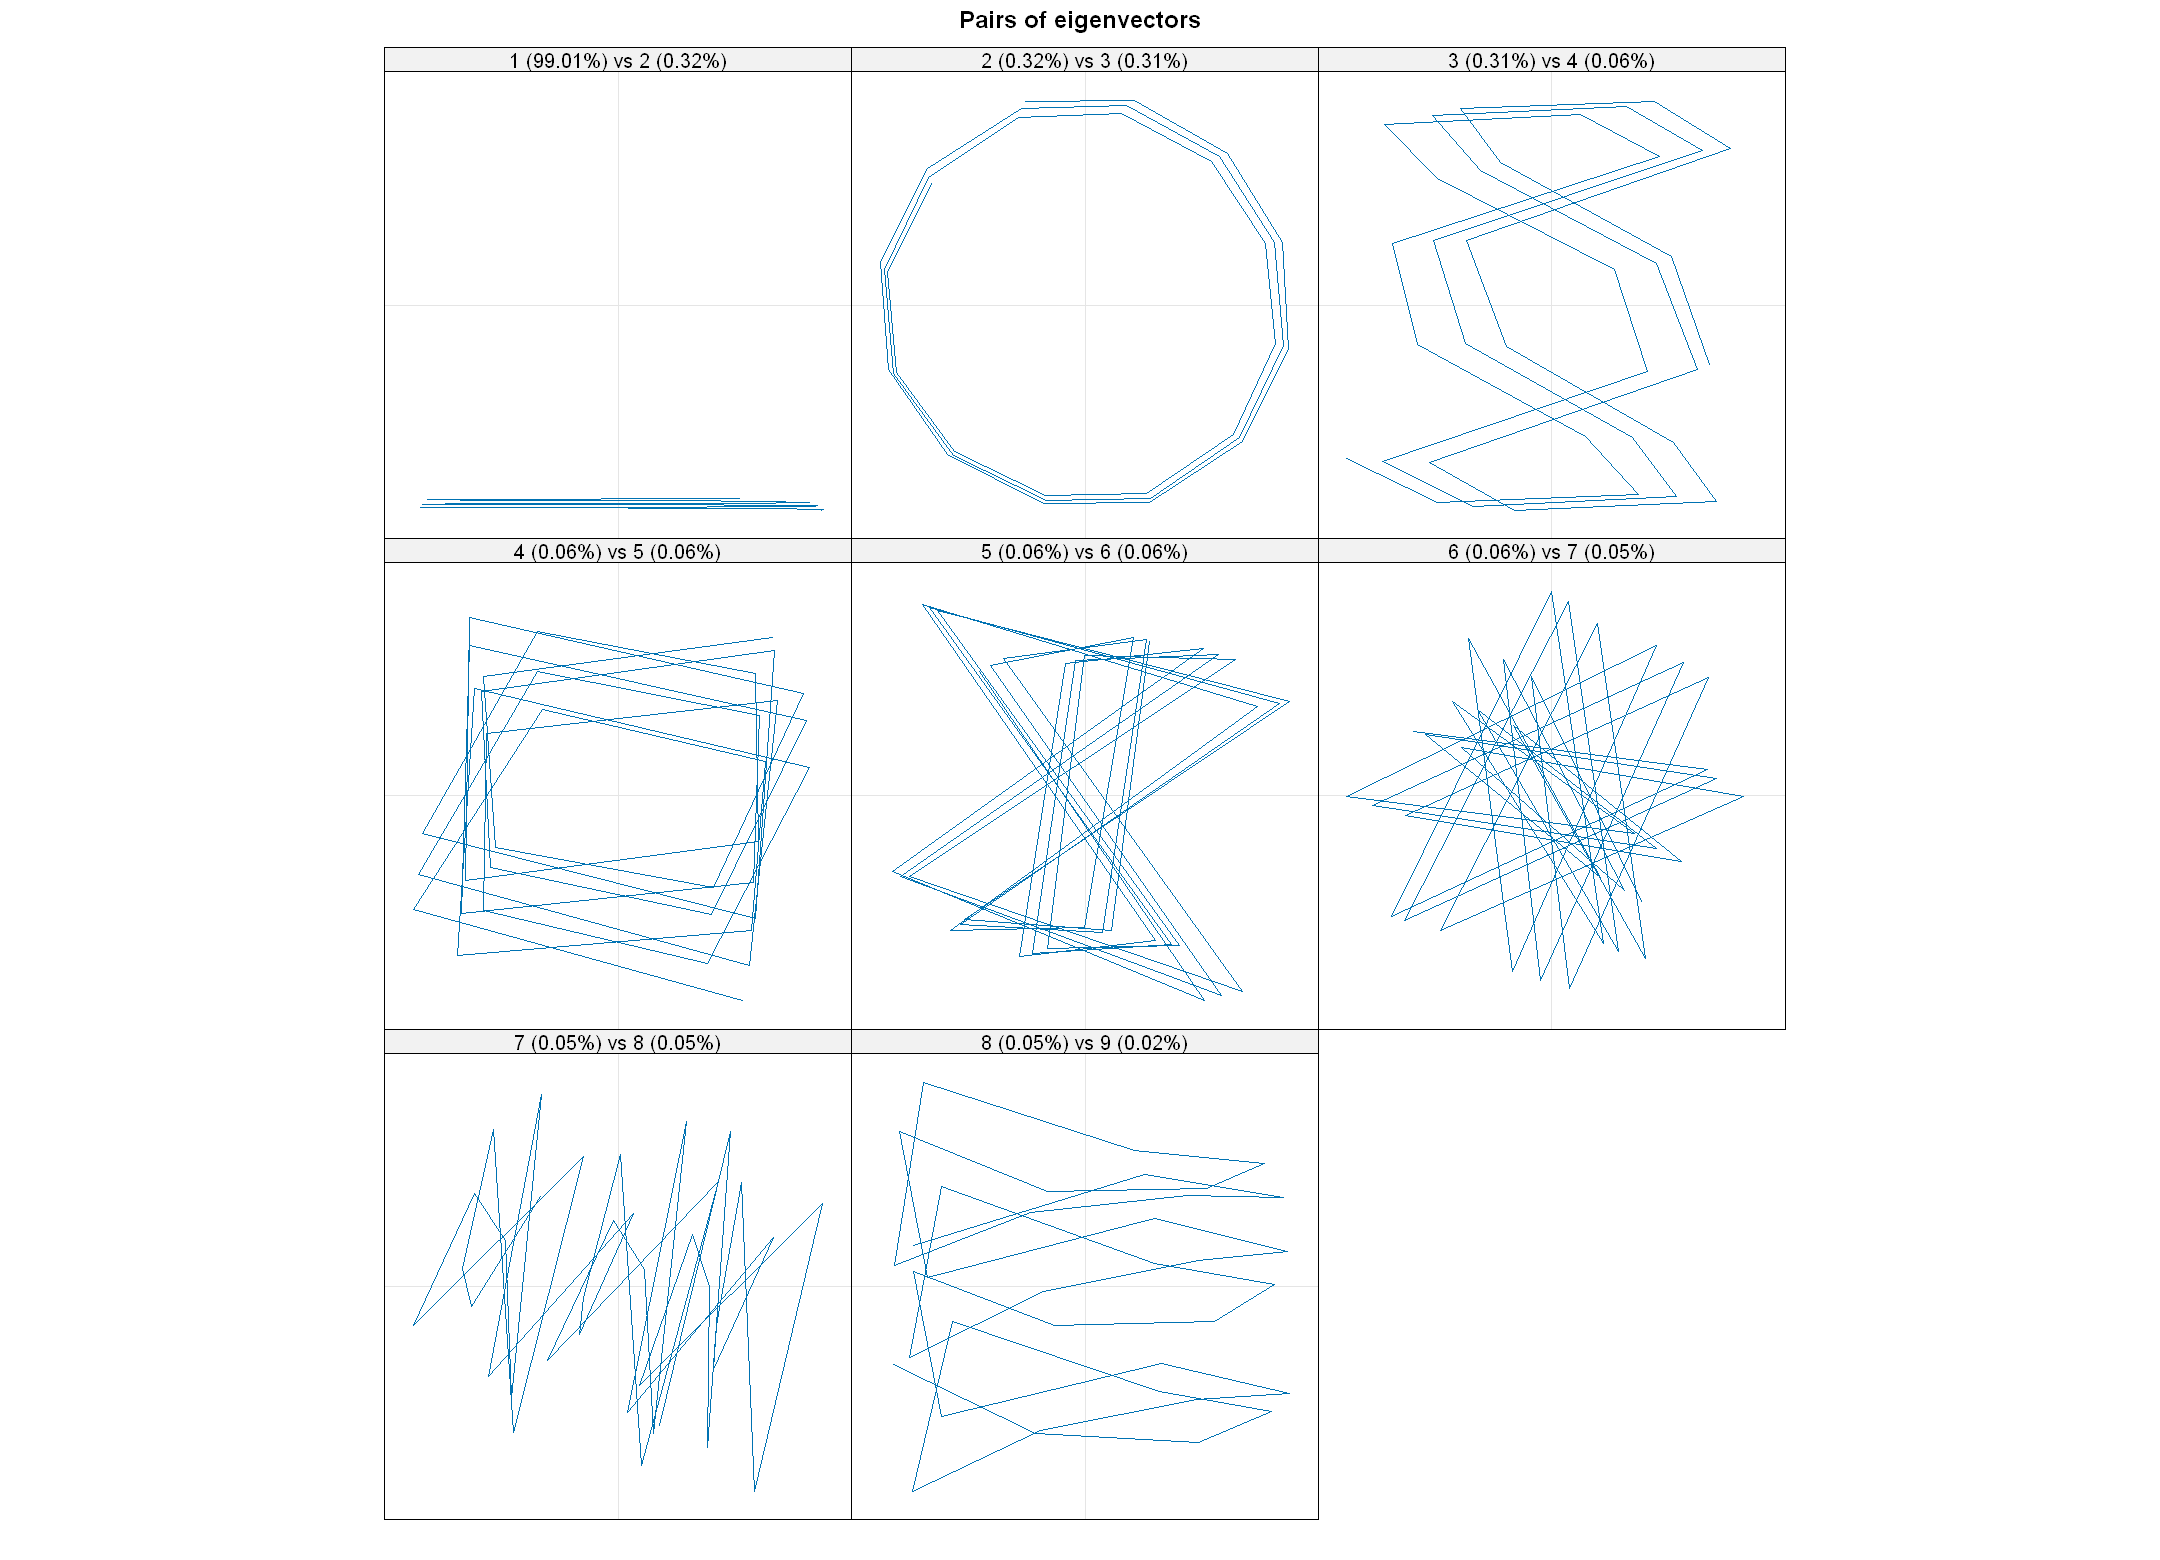

In [31]:
plot(ssaAT, type = "paired", idx = 1:8)

## Plot Korelasi Antar Komponen

Plot ini membantu mengidentifikasi dan mengelompokkan komponen yang saling terkait.

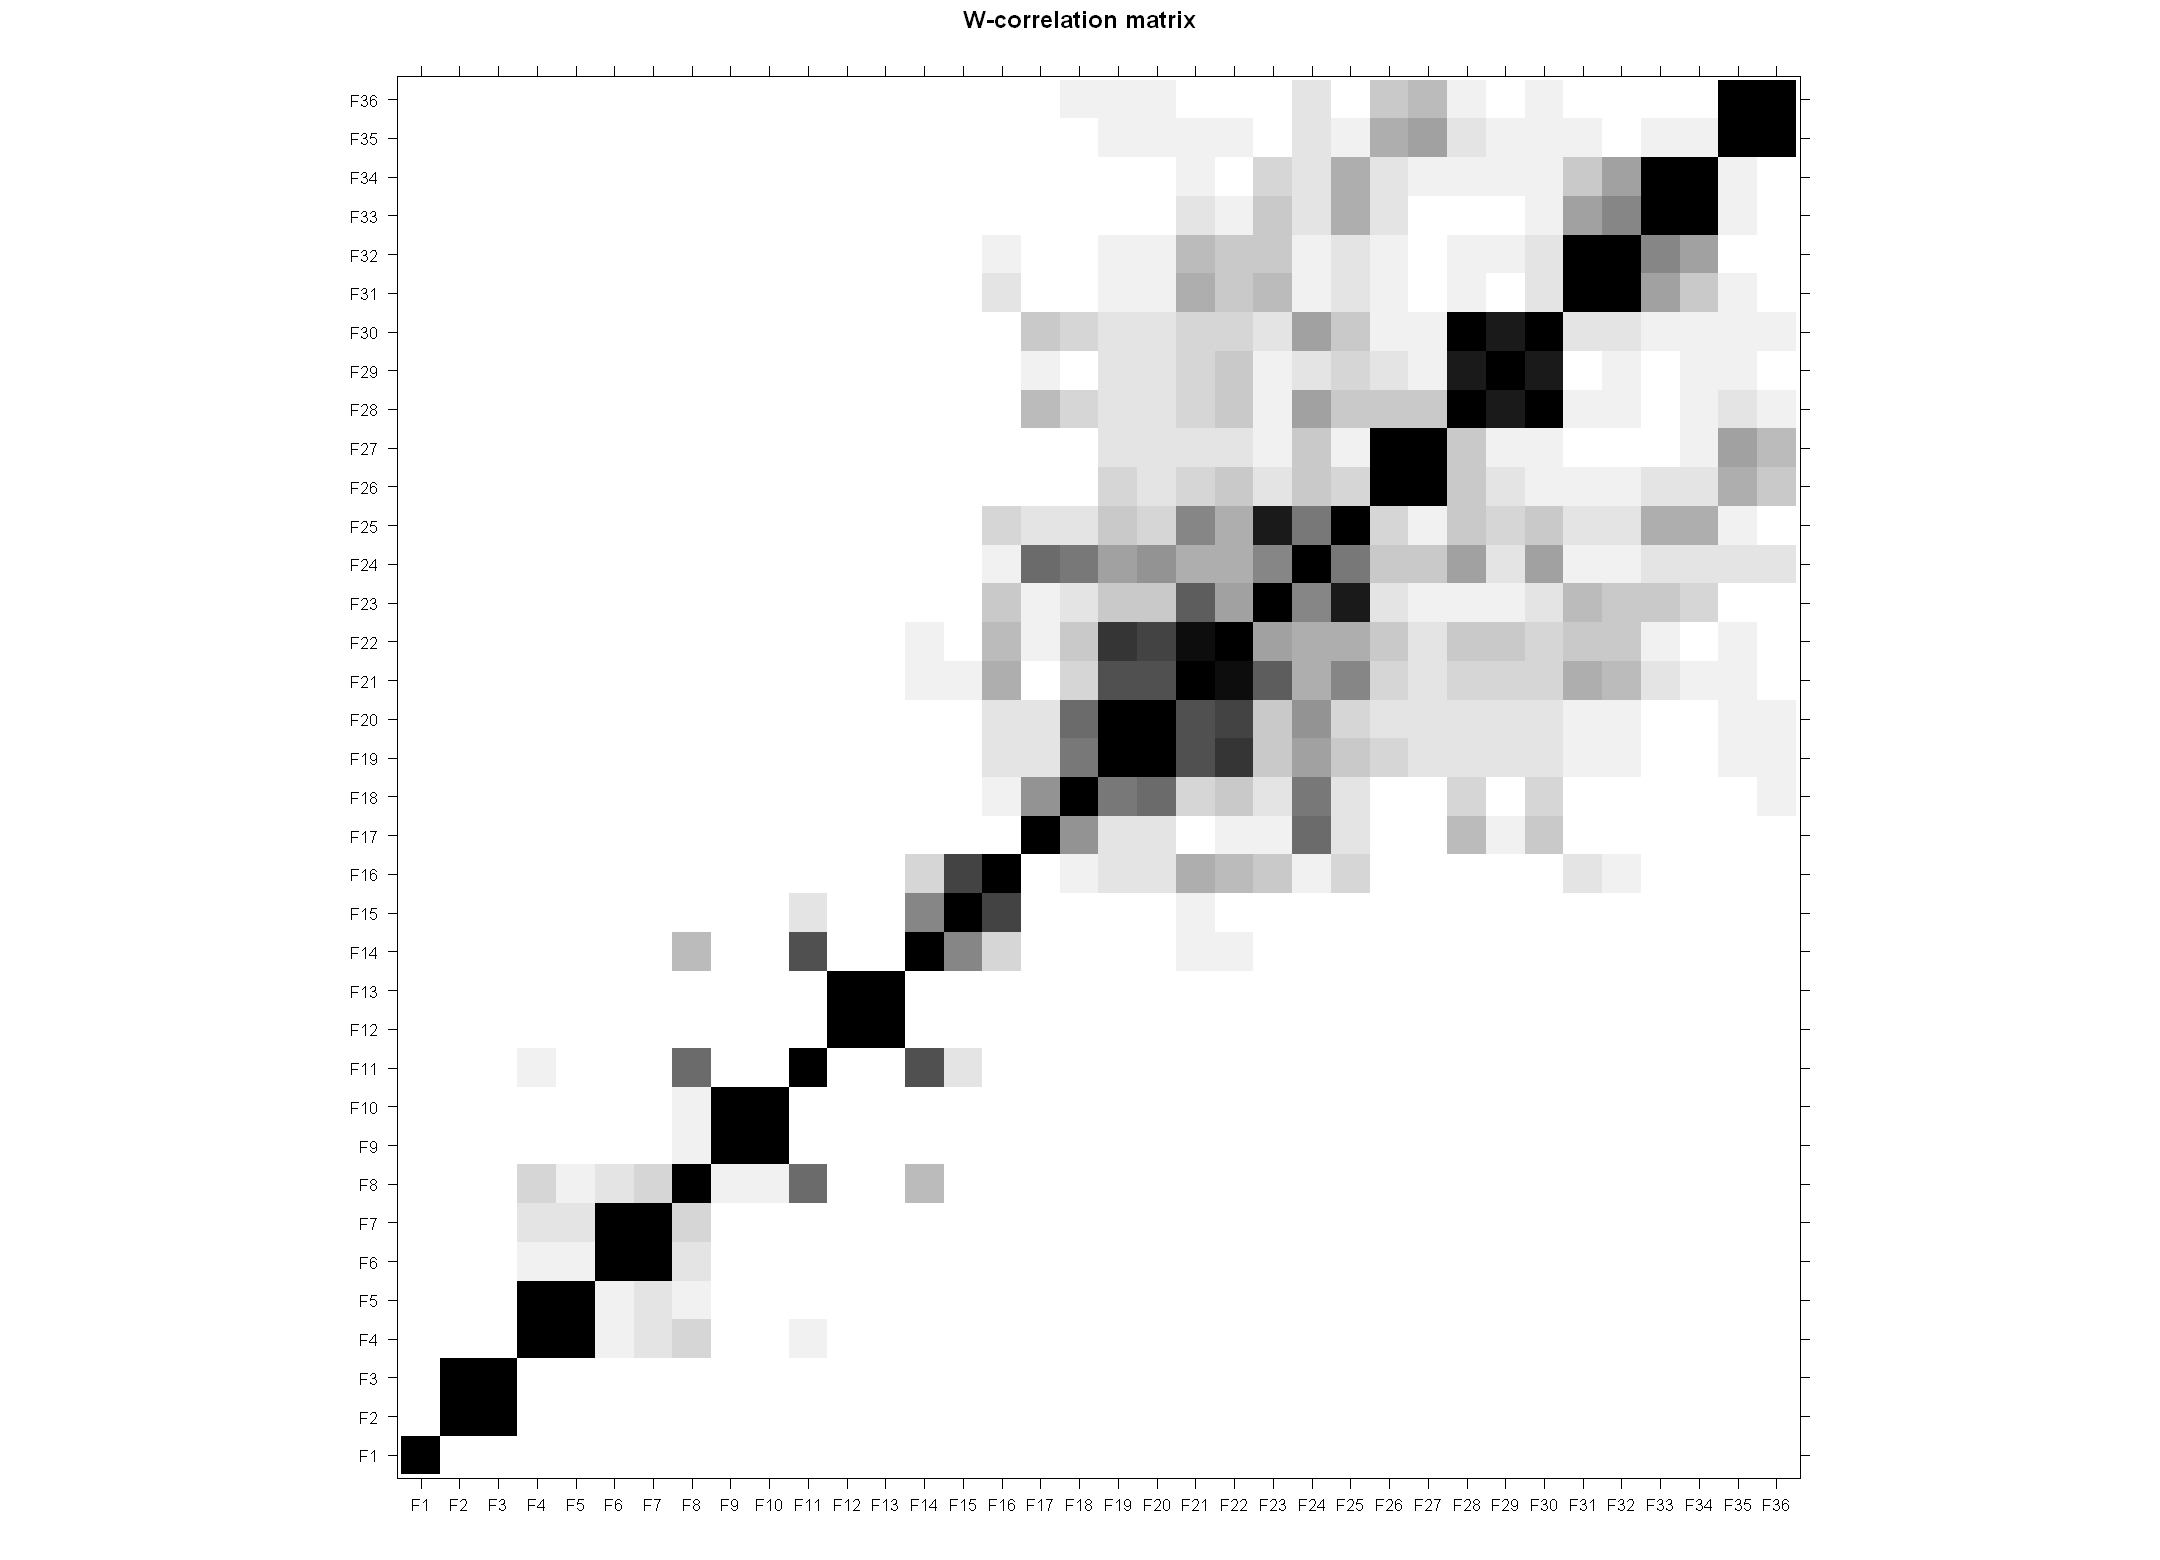

In [32]:
options(repr.plot.width=18, repr.plot.height=13)
plot(wcor(ssaAT))

## Plot Korelasi Komponen Yang Berkorelasi

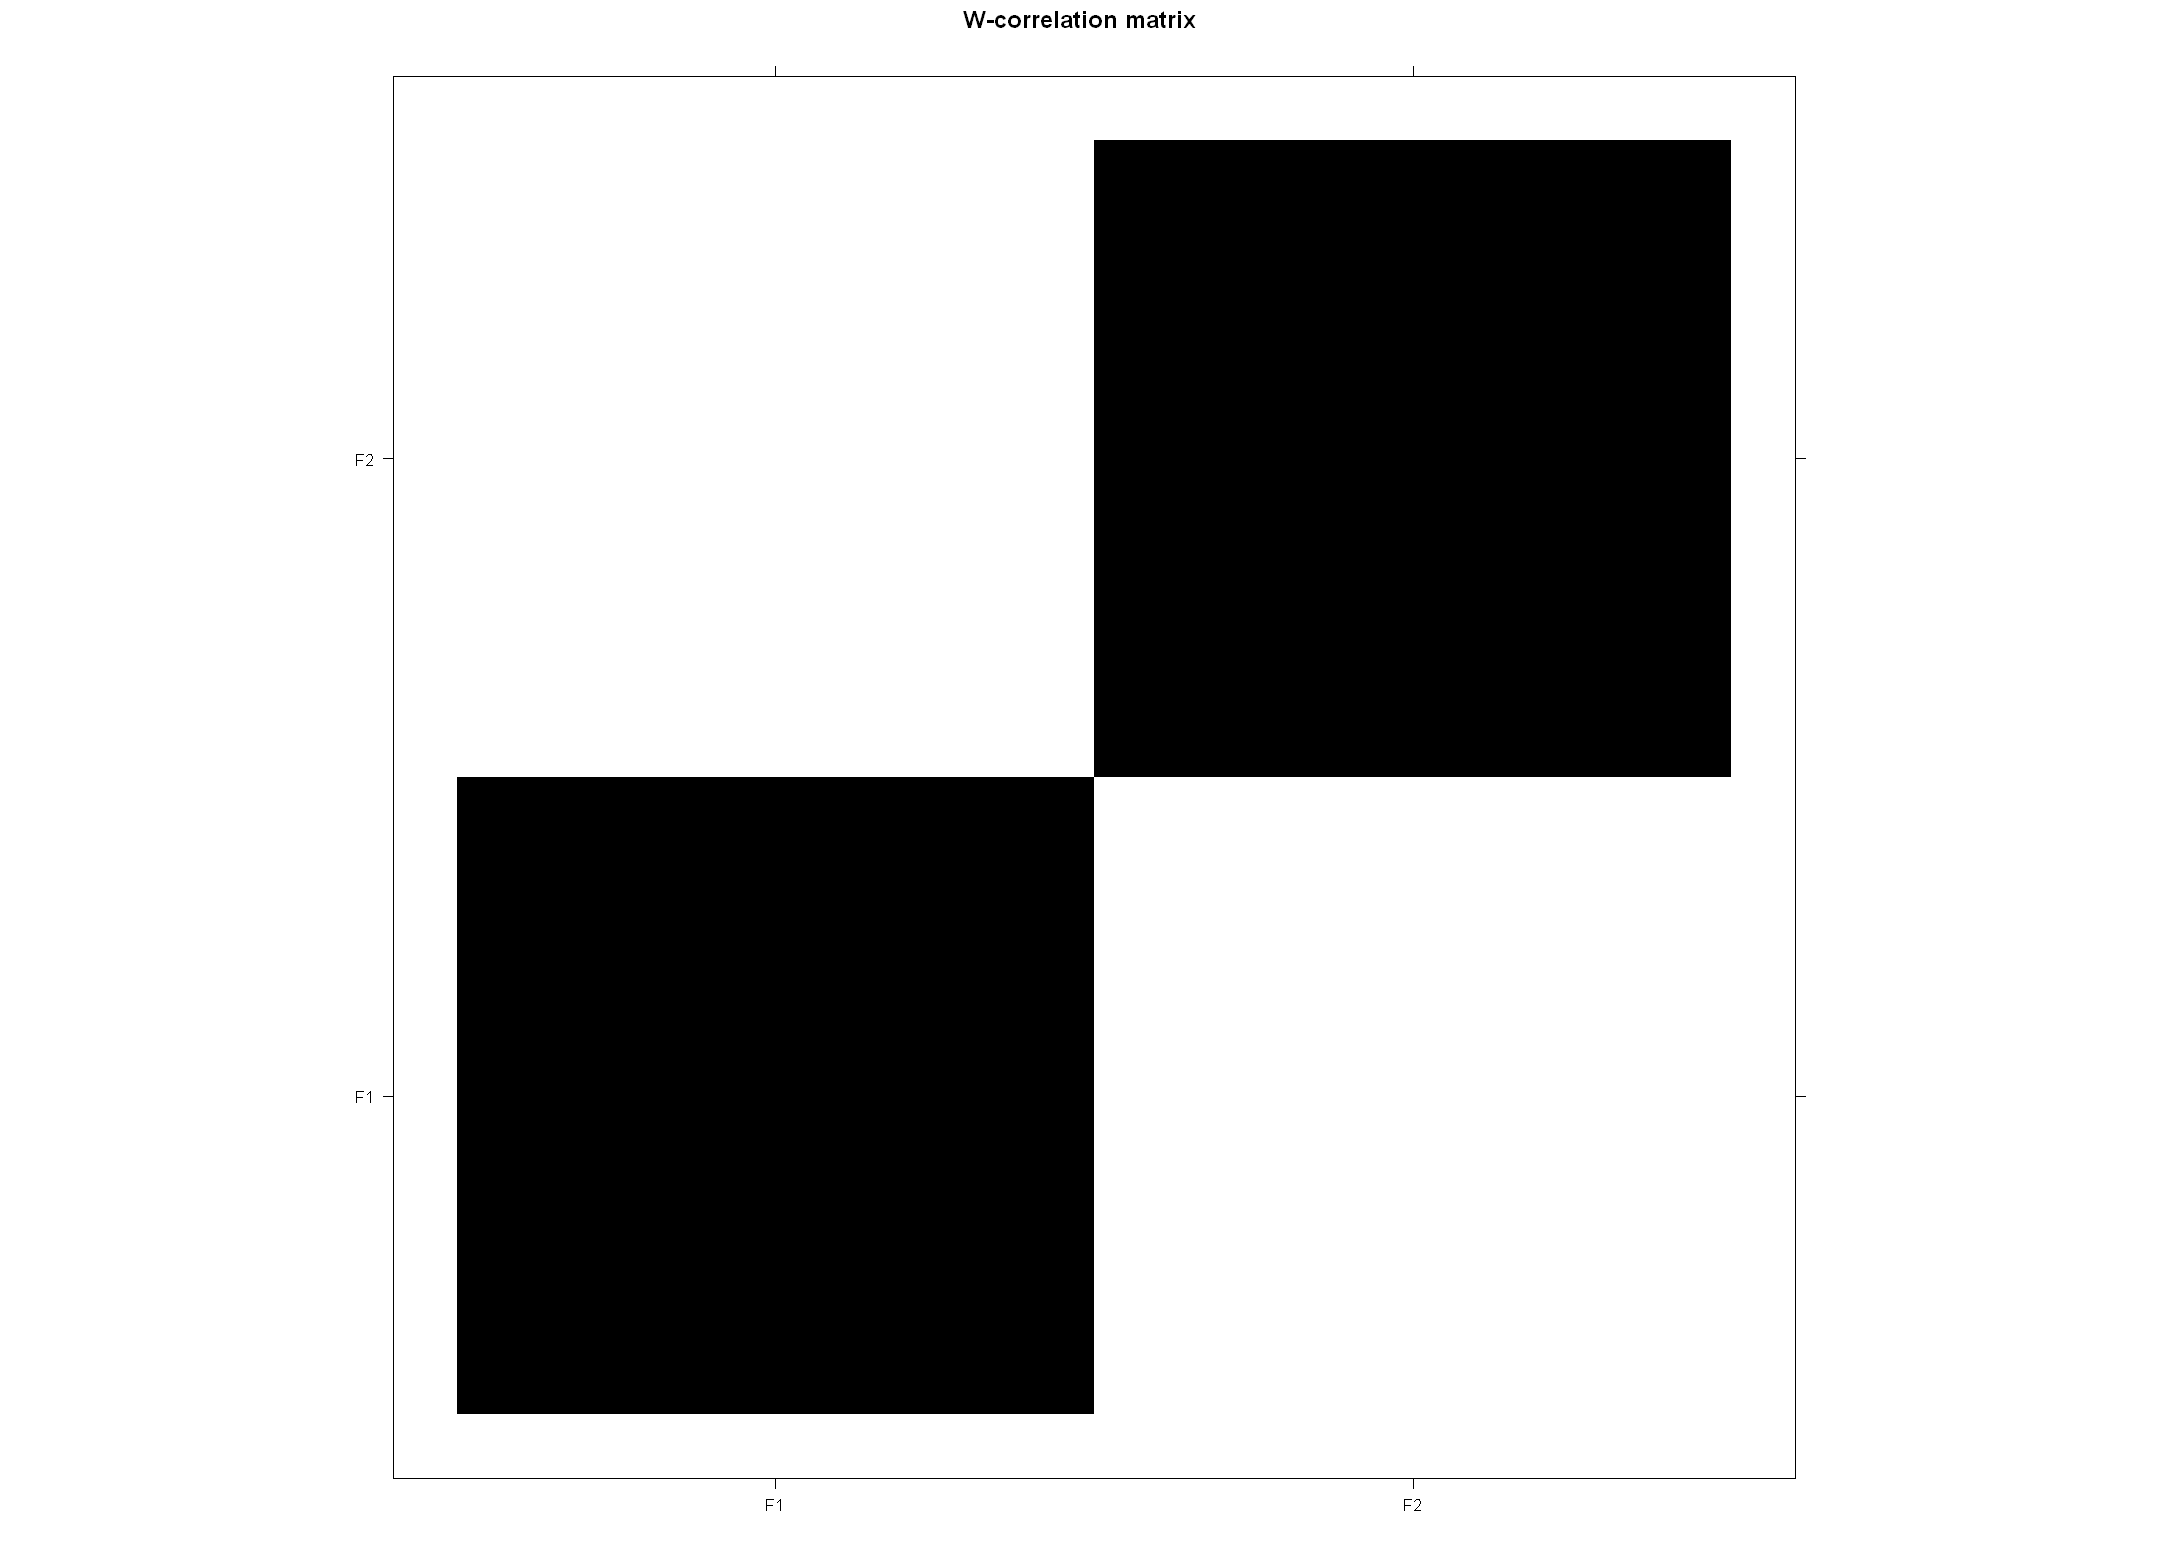

In [33]:
plot(wcor(ssaAT, groups = list(1, c(2,3))))

# Rekonstruksi

Tahap rekonstruksi digunakan untuk membangun kembali deret waktu dari komponen-komponen yang dihasilkan oleh dekomposisi SSA.  
Pada tahap ini rekonstruksi hanya menggunakan komponen-komponen yang relevan sehingga tidak menggunakan komponen noise.

In [34]:
reconAT <- reconstruct(ssaAT, 
                       groups = list(Trend = 1, 
                                     Musim_Harian1 = c(2,3)))

## Plot Rekonstruksi

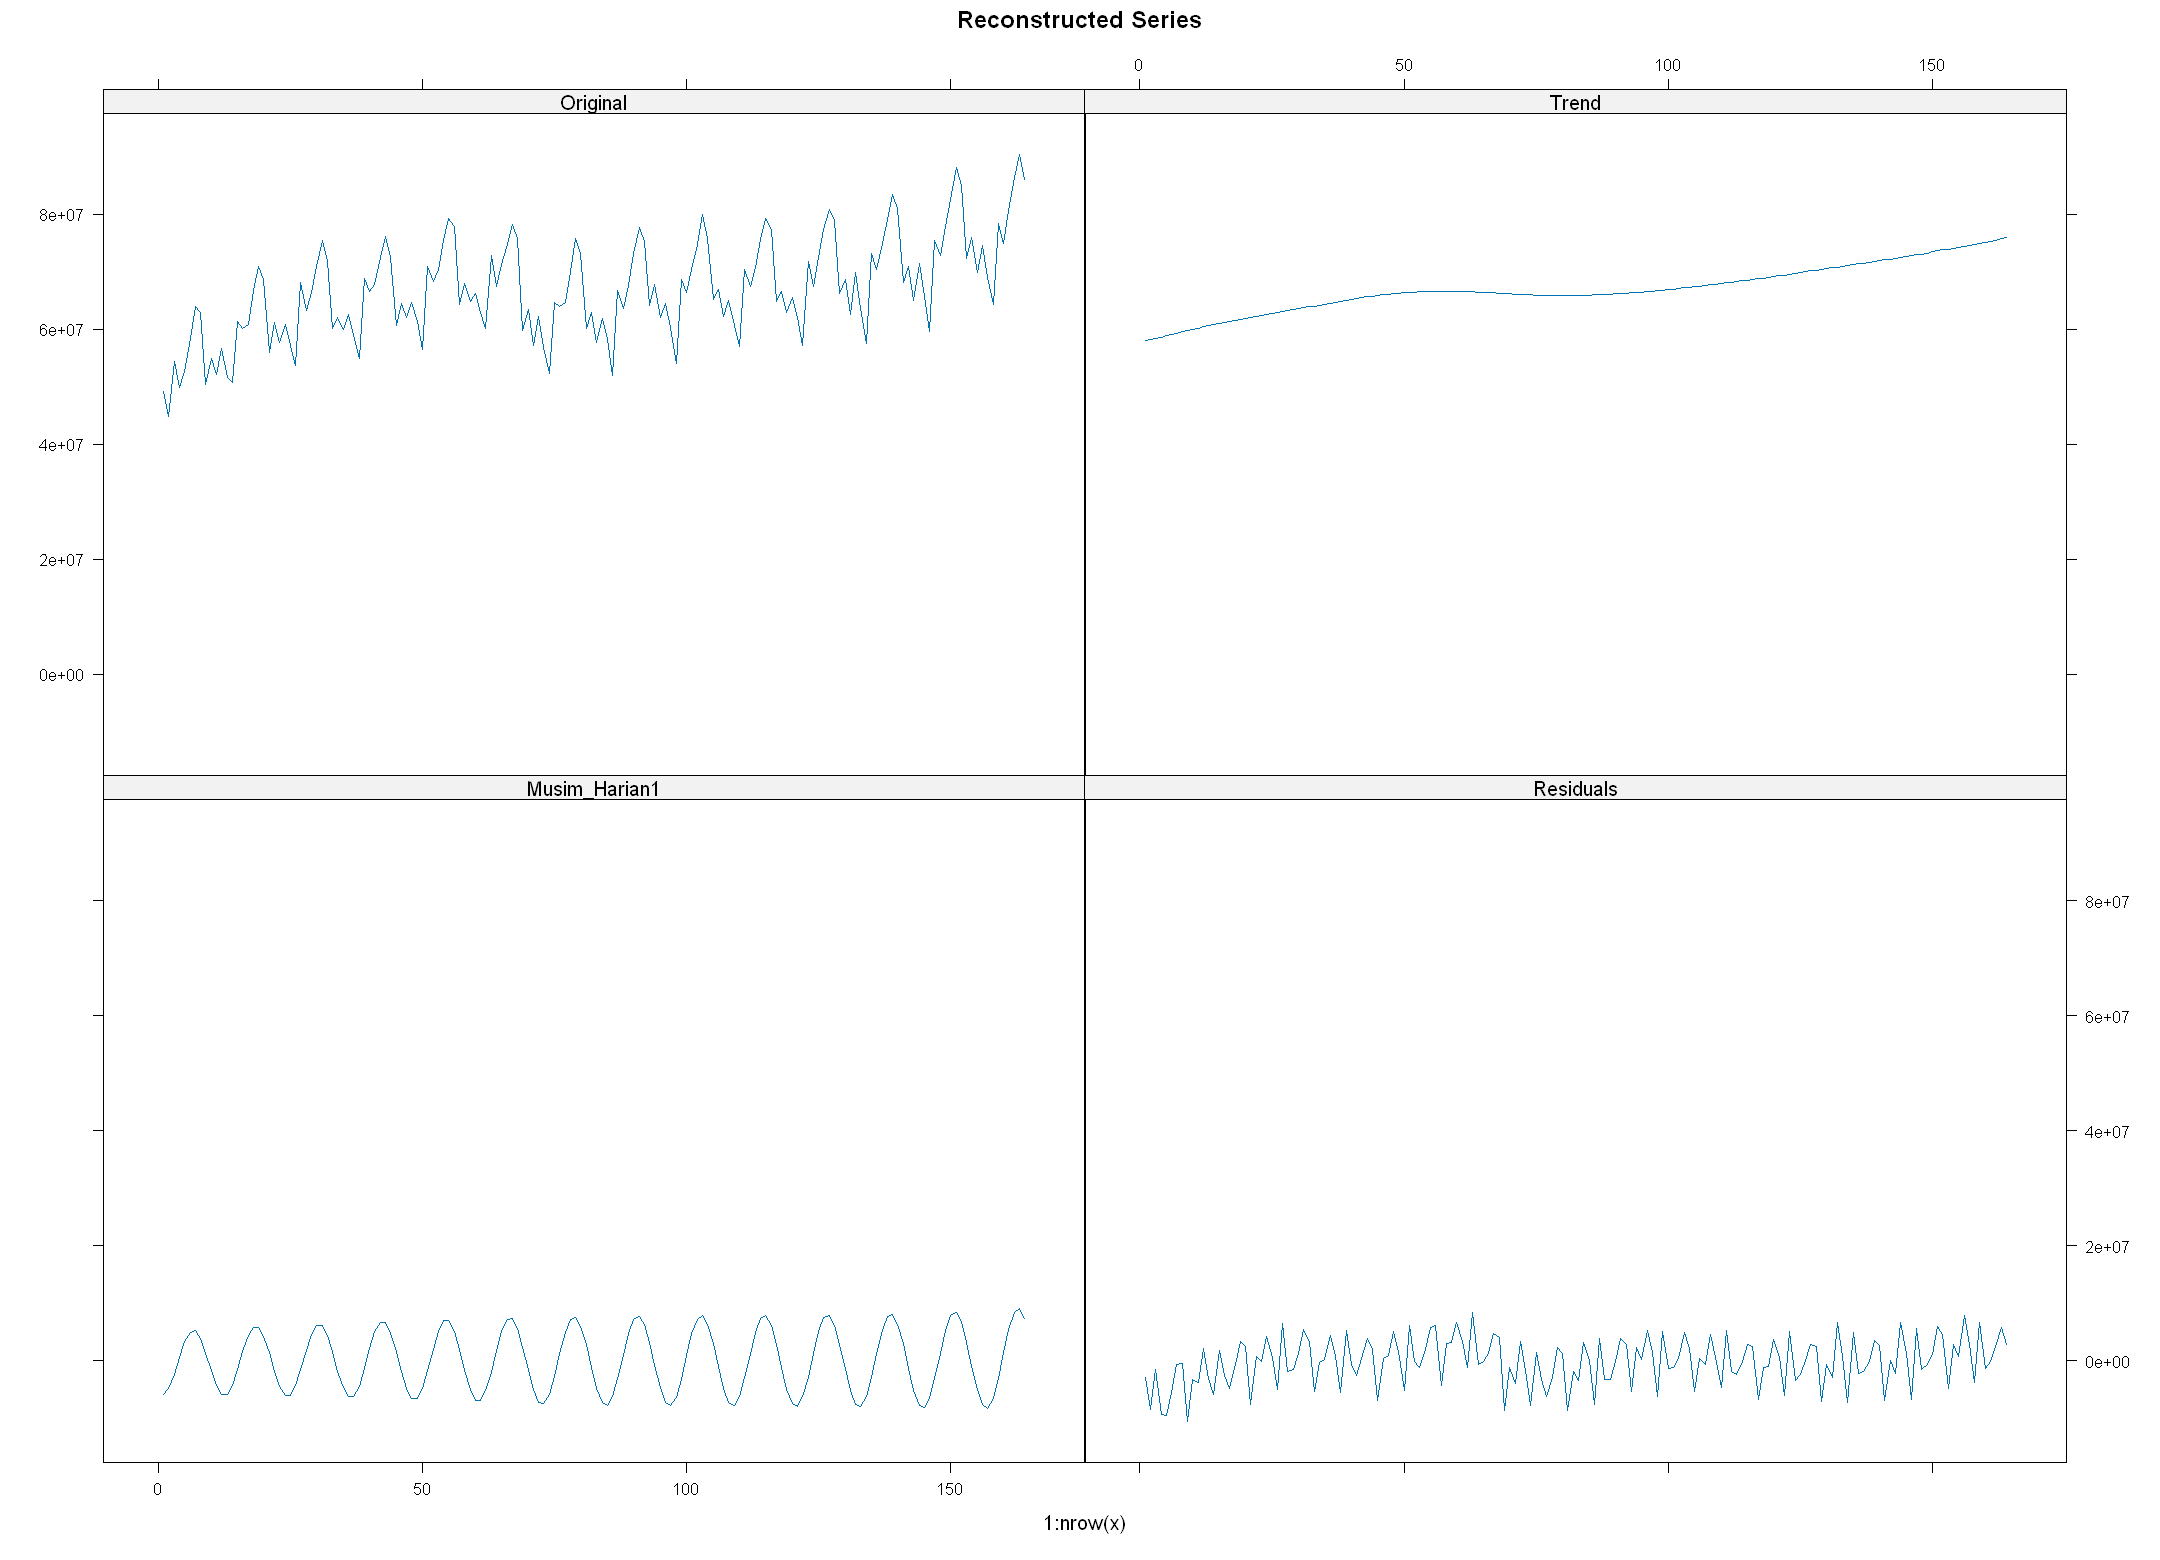

In [35]:
plot(reconAT, add.residuals = TRUE, add.original = TRUE,
     plot.method = "xyplot", superpose = TRUE)

# Estimasi Periode

Tahapan ini membantu mengonfirmasi pola musiman dalam data.

In [36]:
periods_main <- parestimate(ssaAT, groups = list(c(2,3)), method = "esprit")$periods
print(periods_main)

[1]  12.06373 -12.06373


Hasil estimasi periode menunjukkan angka 12, artinya data dikonfirmasi memiliki pola 12 bulan.

# Rekonstruksi Sinyal Utama

Tahapan ini hampir sama dengan tahapan Rekonstruksi, hanya saja mengelompokkan pada komponen 1-5. Dimana akan mencakup trend (komponen 1), musiman (komponen 2-3), dan komponen yang signifikan (4-5).

Sinyal ini nanti akan digunakan dalam tahap forecast

In [37]:
recon_signal <- reconstruct(ssaAT, groups = list(Sinyal = 1:5))
sinyalAT <- recon_signal$Sinyal
residuAT <- residuals(recon_signal)

# Peramalan

Terdapat dua peramalan, yaitu recurrent forecast dan vector forecast. Peramalan dilakukan pada data test sehingga nanti dapat dievaluasi.

Recurrent Forecast (`rforecast`) -> Forecast dilakukan secara bertahap (recurrent), menggunakan pola dari komponen yang dipilih untuk meramalkan nilai berikutnya berdasarkan nilai sebelumnya. Menggunakan tiga grup komponen : (1) untuk trend, (2, 3) untuk musiman, dan (1:5) untuk sinyal.

In [38]:
ramal_r <- rforecast(ssaAT,
                     groups = list(Trend=1, Musim=c(2,3), Sinyal=1:5),
                     len = test_size,
                     only.new = FALSE)

Vector Forecast (`vforecast`) -> Forecast dilakukan secara simultan untuk semua titik waktu, menggunakan proyeksi linear dari komponen. Menggunakan grup komponen sinyal (1:5) sebagai grup utama atau sinyal utama.

In [39]:
ramal_v <- vforecast(ssaAT,
                     groups = list(1:5),
                     len = test_size,
                     only.new = FALSE)

## Plot Forecasting

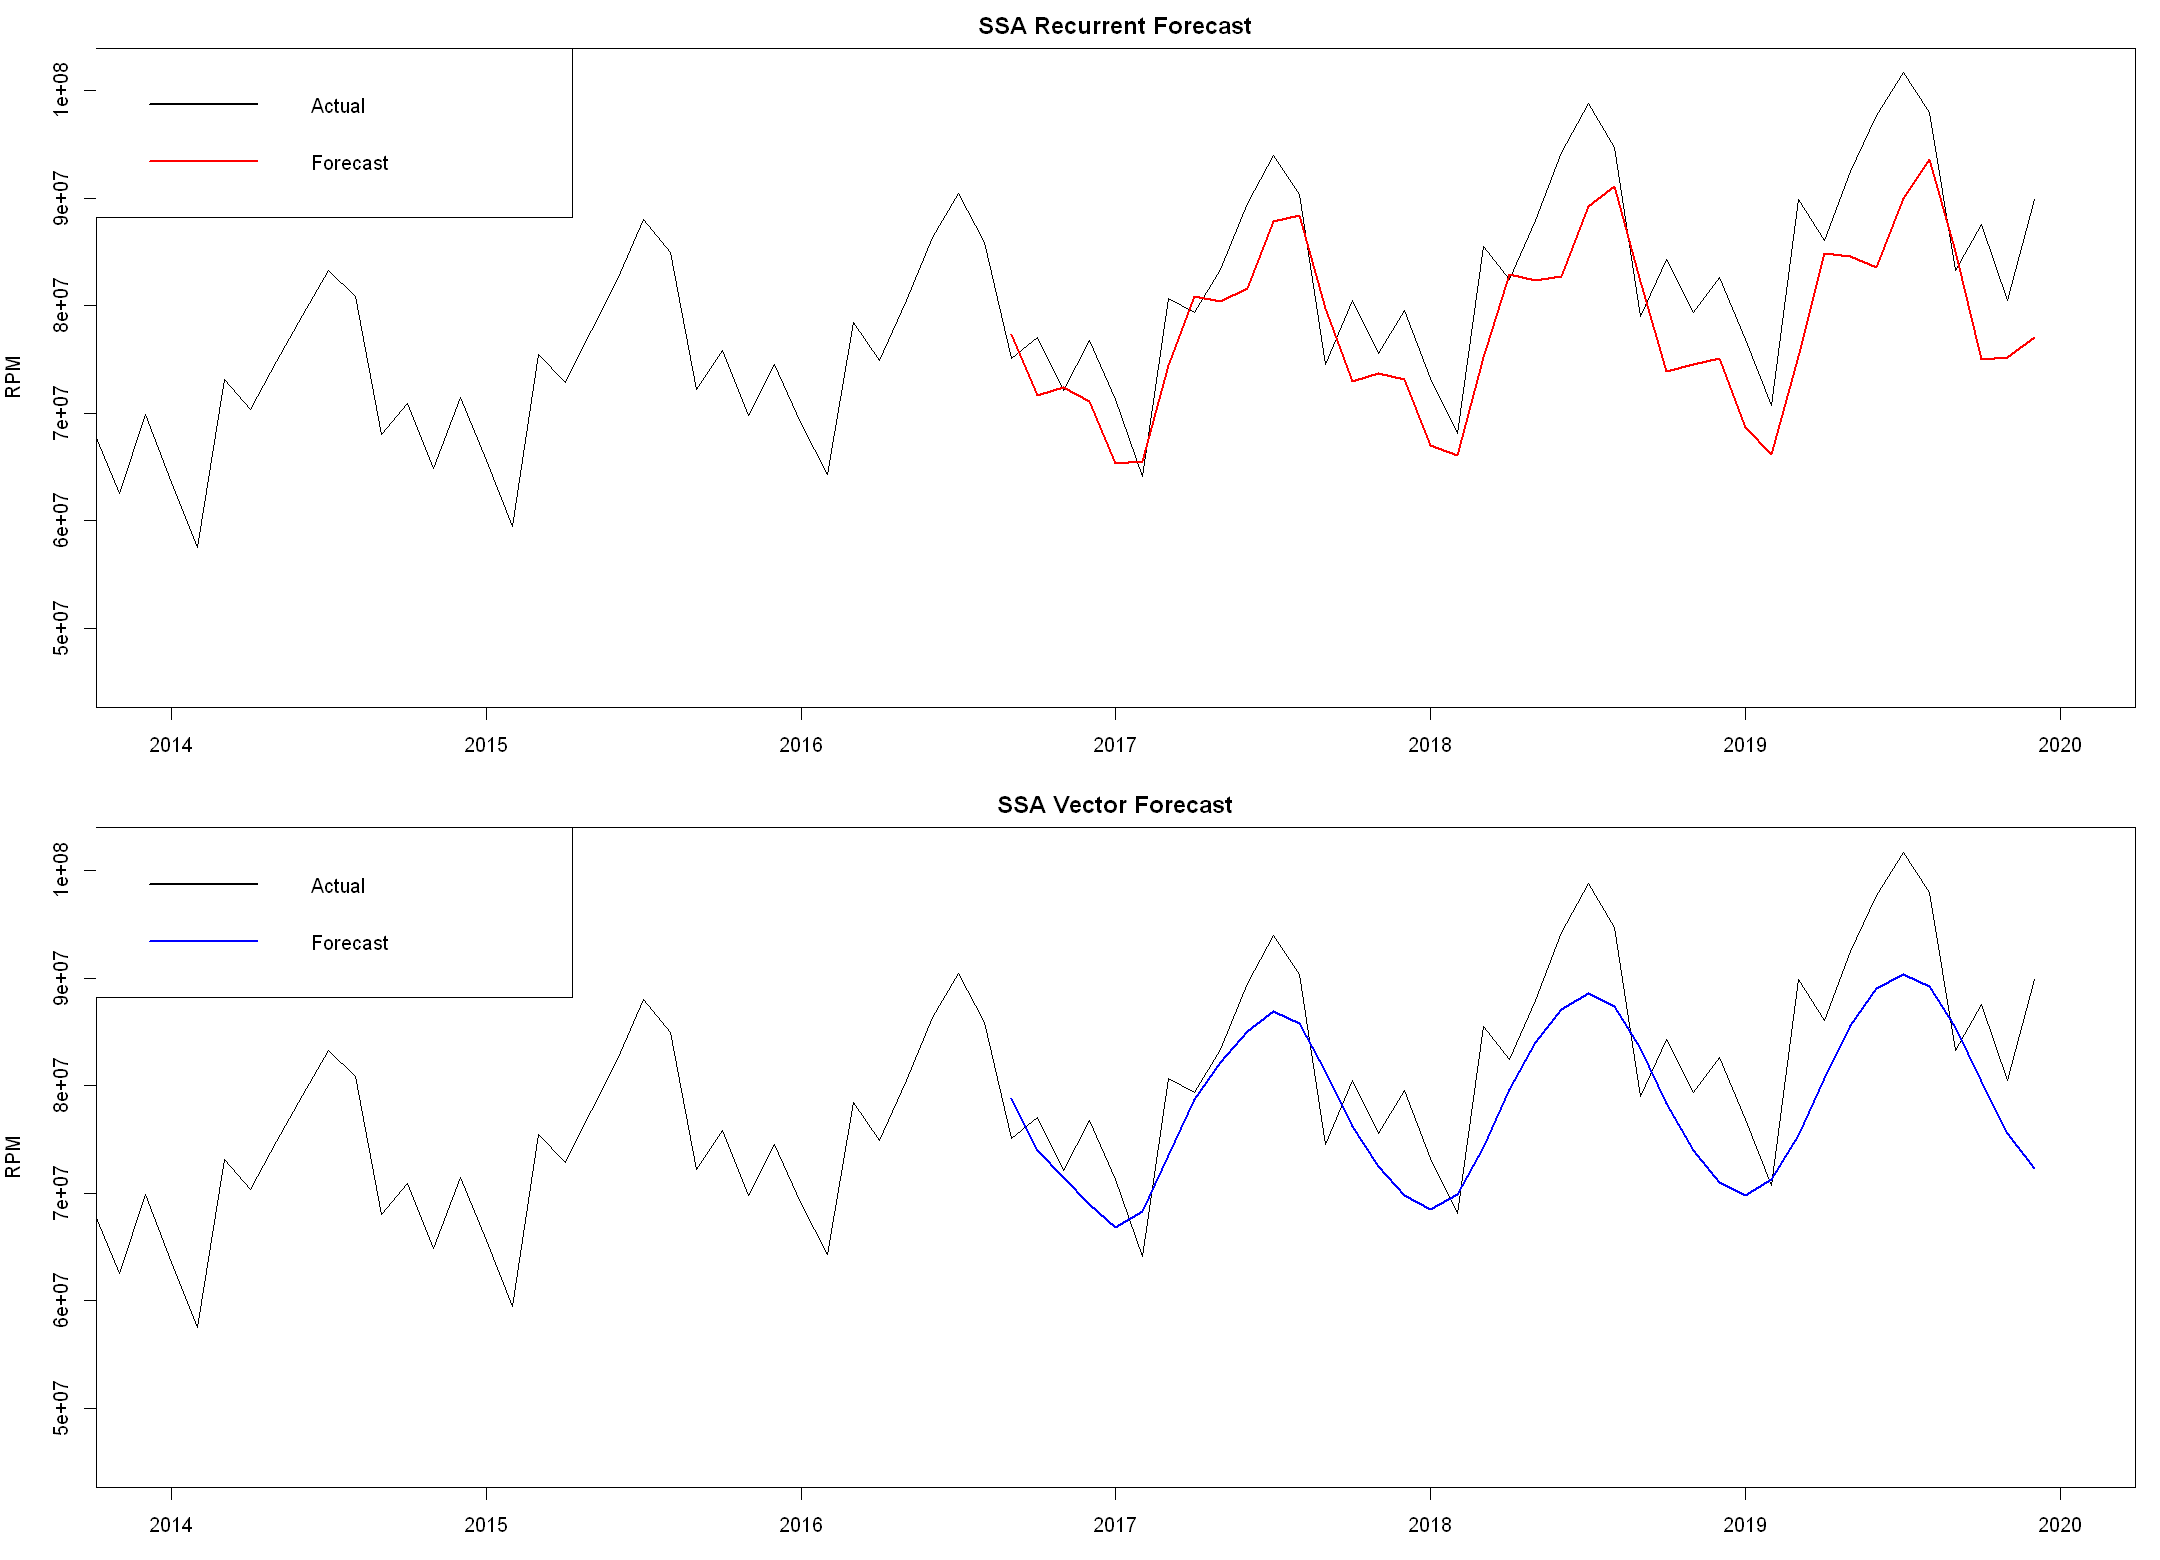

In [40]:
# Plot forecasting (pakai index waktu dari data ts asli)
par(mfrow = c(2,1), mar = c(3,4,2,1))

freq <- frequency(data)
train_len <- length(train)
test_start <- c(floor(time(data)[train_len + 1]), cycle(data)[train_len + 1])

actual_full <- ts(c(as.numeric(train), as.numeric(test)),
                  frequency = freq,
                  start = start(data))

forecast_r <- ts(as.numeric(tail(ramal_r$Sinyal, test_size)),
                 frequency = freq,
                 start = test_start)

forecast_v <- ts(as.numeric(tail(ramal_v, test_size)),
                 frequency = freq,
                 start = test_start)

plot(actual_full,
     type = "l", col = "black", lwd = 1.5,
     main = "SSA Recurrent Forecast", xlab = "Time", ylab = "RPM", xlim = c(2014, 2020))
lines(forecast_r, col = "red", lwd = 2)
legend("topleft", c("Actual", "Forecast"), col = c("black", "red"), lty = 1, lwd = 2)

plot(actual_full,
     type = "l", col = "black", lwd = 1.5,
     main = "SSA Vector Forecast", xlab = "Time", ylab = "RPM", xlim = c(2014, 2020))
lines(forecast_v, col = "blue", lwd = 2)
legend("topleft", c("Actual", "Forecast"), col = c("black", "blue"), lty = 1, lwd = 2)

Forecast recurrent tampak mengikuti pola aktual dengan baik, menangkap tren umum, dan pola musiman tahunan. Namun, ada deviasi kecil di beberapa titik yang mungkin menunjukkan bahwa metode ini mungkin kurang presisi untuk variasi jangka pendek atau noise.

Forecast vector juga menunjukkan mengikuti pola aktual cukup baik, terutama dalam menangkap tren dan musiman. Dibandingkan recurrent, vector mungkin lebih stabil untuk proyeksi jangan panjang karena pendekata simultan tetapi juga bisa kurang responsif terhadap perubahan mendadak.

# Evaluasi

In [41]:
# Fungsi akurasi
accuracy_metrics <- function(actual, forecast) {
  error <- actual - forecast
  rmse <- sqrt(mean(error^2))
  mae <- mean(abs(error))
  mape <- mean(abs(error/actual)) * 100
  cat("RMSE :", round(rmse, 4), "\n")
  cat("MAE  :", round(mae, 4), "\n")
  cat("MAPE :", round(mape, 2), "%\n")
}

cat("\n=== Recurrent Forecast Accuracy ===\n")
accuracy_metrics(test, tail(ramal_r$Sinyal, test_size))

cat("\n=== Vector Forecast Accuracy ===\n")
accuracy_metrics(test, tail(ramal_v, test_size))


=== Recurrent Forecast Accuracy ===
RMSE : 7213633 
MAE  : 6084548 
MAPE : 7.13 %

=== Vector Forecast Accuracy ===


RMSE : 7163848 
MAE  : 6122470 
MAPE : 7.18 %


In [42]:
lrr.coef <- lrr(ssaAT, groups = list(1:5))
print(lrr.coef)

 [1]  0.040699751 -0.031138835  0.044135226  0.046658262 -0.046180235
 [6] -0.137418044 -0.017884635  0.060939459 -0.005724281 -0.007225599
[11]  0.087251752  0.180809570  0.059312848 -0.014273082  0.058368121
[16]  0.062842829 -0.028136699 -0.121929292 -0.003499920  0.077842162
[21]  0.014371711  0.012549270  0.105263519  0.203122417  0.082892522
[26]  0.006253248  0.076213541  0.079258638 -0.010667096 -0.108571307
[31]  0.006503164  0.086741225  0.025422813  0.022327052  0.113244319
attr(,"class")
[1] "lrr"
